In [1]:
import pyforest
import scipy.stats as st

In [3]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [2]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova  import anova_lm 

In [2]:
#df= pd.read_csv('StudentsPerformance-1.csv')

<IPython.core.display.Javascript object>

In [12]:
df=pd.read_csv('C:\\Users\\Chidi\\Desktop\\statitics methods and decisionmaking\\StudentsPerformance.csv')
df.head()

<IPython.core.display.Javascript object>

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,female,group B,standard,none,89,55,56,200,Nature Learning
1,female,group C,standard,completed,55,63,72,190,Nature Learning
2,female,group B,standard,none,64,71,56,191,Nature Learning
3,male,group A,free/reduced,none,60,99,72,231,Nature Learning
4,male,group C,standard,none,75,66,51,192,Nature Learning


In [13]:
df.head()

,gender,race/ethnicity,lunch,test preparation course,math score,reading score,writing score,total score,training institute
0,female,group B,standard,none,89,55,56,200,Nature Learning
1,female,group C,standard,completed,55,63,72,190,Nature Learning
2,female,group B,standard,none,64,71,56,191,Nature Learning
3,male,group A,free/reduced,none,60,99,72,231,Nature Learning
4,male,group C,standard,none,75,66,51,192,Nature Learning


In [14]:
df.columns

Index(['gender', 'race/ethnicity', 'lunch', 'test preparation course',
       'math score', 'reading score', 'writing score', 'total score',
       'training institute'],
      dtype='object')

In [15]:
df.groupby('ethnicity')['total_score'].describe()

KeyError: 'ethnicity'

In [10]:
d.groupby('race')['total_score'].describe()

KeyError: 'race'

In [16]:
df.groupby('ethnicity')['total_score'].plot(kind= 'kde')

KeyError: 'ethnicity'

<IPython.core.display.Javascript object>

<AxesSubplot:xlabel='ethnicity', ylabel='total_score'>

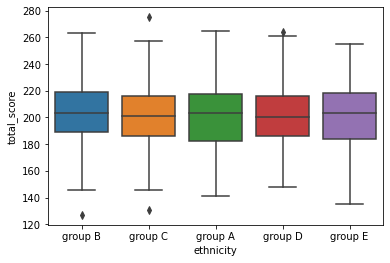

In [12]:
sns.boxplot(y=df.total_score, x=df.ethnicity)

In [15]:
AT= df[df.ethnicity=='group A']['total_score']
BT= df[df.ethnicity=='group B']['total_score']
CT= df[df.ethnicity=='group C']['total_score']
DT= df[df.ethnicity=='group D']['total_score']
ET= df[df.ethnicity=='group E']['total_score']

In [16]:
st.levene(AT,BT, CT, DT,ET)

LeveneResult(statistic=1.8006030590828939, pvalue=0.12649444001357793)

In [7]:
df['ethnicity']=df['race/ethnicity']
df['total_score']= df['total score']

Assumptions: normality( shapiro) and levene ( variance equality)

H0: all the pop means are same

H1: at least one population is different from the rest;

In [8]:
m1= ols('total_score~ethnicity', data=df).fit()
anova_table= anova_lm(m1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
ethnicity,4.0,1699.671655,424.917914,0.78911,0.532294
Residual,995.0,535785.303345,538.477692,NaN,NaN


In [2]:
df= sns.load_dataset('tips')

<IPython.core.display.Javascript object>

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


The restaurent manager claims that the average total bill is $20. test this claim at 95% level of confidence or 5% level of significance?

In [ ]:
# Step 0: Normality test - Shapiro test
# Note: if the sample size >30 not required to test else we test 



In [4]:
## Normality test : 
## H0: pop data = nornal
## H1: pop data !=normal

In [5]:
st.shapiro(df.total_bill)

ShapiroResult(statistic=0.9197188019752502, pvalue=3.3245434183371003e-10)

since p value (close to 0) <alpha(0.05) --> reject H0 

Hence the population data is not normal

since the normality is failed we need to proceed for non parametric test(wilcoxon test);

H0: pop median = 20
H1: pop median !=20

In [9]:
df.total_bill.median()

17.795

In [11]:
population_median= 20
med_data= df.total_bill-population_median
st.wilcoxon(med_data)

WilcoxonResult(statistic=12643.5, pvalue=0.03703500887146945)

since p value(0.03) < alpha(0.05) --> Reject H0;
hence we conclude that the sample does not belongs to the population whose median is $20.

In [4]:
# step 1: state H0 & H1 & level of significance(alpha)

# H0: mu_tb = 20
# H1: mu_tb != 20
alpha=0.05

In [5]:
# step 2: select appropriate test and compute corresponding 
# test statistic
# one sample  t test of mean( unknown population standard deviation)
#t_statistic= (xbar-hypothesis(population) mean)/std_error

In [6]:
mu=20
n=len(df.total_bill)
xbar= df.total_bill.mean()
s= df.total_bill.std()
std_error= s/np.sqrt(n)
t_statistic= (xbar-mu)/std_error
print(t_statistic)

<IPython.core.display.Javascript object>

-0.37559294451918884


In [8]:
talphaby2=st.t.ppf(alpha/2, n-1)
print(talphaby2)

-1.9697743954258797


In [ ]:
## Critical Value approach: ( Decision rule)
## If abs(test statistic)< abs(ctitical value)--> fail; to reject H0 
##   else reject H0
# since abs(-0.375) < abs(-1.96) ---> fail to reject H0
## It means that the sample is drawn from a population whose mean is $20


Conclusion: the claim by restaurent manager is true

In [9]:
st.t.interval(1-alpha,n-1,xbar, s/np.sqrt(n))

<IPython.core.display.Javascript object>

(18.663331704358477, 20.90855354154317)

In [ ]:
## Confidence Interval  approach: ( Decision rule)
## If hypothesis value falls in the confidence interval --> fail; to reject H0 
##   else reject H0
# since 20 falls between 18.66 to 20.90  ---> fail to reject H0
## It means that the sample is drawn from a population whose mean is $20


Conclusion: the claim by restaurent manager is true

In [10]:
p_value = st.t.cdf(t_statistic, n-1)*2
print(p_value)

0.7075471935626767


In [ ]:
## p- value approach: ( Decision rule)
## If p value is greater than alpha  --> fail to reject H0 
##   else reject H0
# since p value = 0.7 > alpha(0.05) ---> fail to reject H0
## It means that the sample is drawn from a population whose mean is $20


In [11]:
st.ttest_1samp(df.total_bill, mu)

Ttest_1sampResult(statistic=-0.37559294451919506, pvalue=0.7075471935626723)

### Test the claim that average total bill is more for  dinner rather than lunch?

In [12]:
df.groupby('time')['total_bill'].describe()

,count,mean,std,min,25%,50%,75%,max
time,,,,,,,,
Lunch,68.0,17.168676,7.713882,7.51,12.2350,15.965,19.5325,43.11
Dinner,176.0,20.797159,9.142029,3.07,14.4375,18.390,25.2825,50.81


time
Lunch     AxesSubplot(0.125,0.125;0.775x0.755)
Dinner    AxesSubplot(0.125,0.125;0.775x0.755)
Name: total_bill, dtype: object

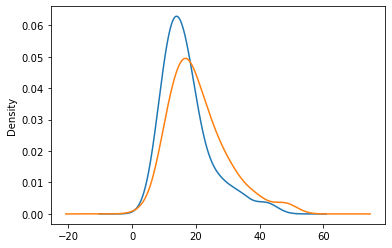

In [13]:
df.groupby('time')['total_bill'].plot(kind='kde')

<IPython.core.display.Javascript object>

<AxesSubplot:xlabel='time', ylabel='total_bill'>

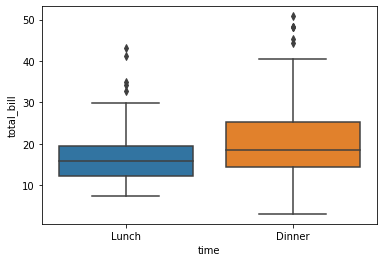

In [15]:
sns.boxplot(y=df.total_bill,x=df.time)

In [16]:
tb_lunch= df[df.time=='Lunch']['total_bill']
tb_dinner= df[df.time=='Dinner']['total_bill']

#Assumption 1: test of normality ( bypass this step as sample  sizes are >30)

In [ ]:
## Assumption -2 : Variance equality test( Levene test)
## H0: pop1 var= pop2 var
## H1: pop1 var != pop 2 var

In [17]:
st.levene(tb_lunch,tb_dinner)

LeveneResult(statistic=2.6906995489829337, pvalue=0.1022346107726258)

since p value(0.1) is > alpha(0.05) --> fail to reject H0;

hence we can say that population varinaces are equal;

In [ ]:
#step 1: H0: mu_tb_dinner <= mu_tb_lunch
##       H1: mu_tb_dinner > mu_tb_lunch


In [19]:
alpha=0.05
## we choose independent 2 samples test of mean ; 
# and since we are not knowing pop varinace --> t test 
# hecne use 2 sample independent t test;
st.ttest_ind(tb_dinner, tb_lunch, equal_var=True,alternative='greater')


Ttest_indResult(statistic=2.8976375218366424, pvalue=0.002052310703797837)

## test of Proportion

Test the restaurent manager claim that 35% of transactions are consuming smoking material @5 % level of significance?

In [22]:
df.smoker.value_counts()

No     151
Yes     93
Name: smoker, dtype: int64

In [25]:
P=0.35
alpha=0.05
x= 93
n= len(df.smoker)
p=x/n
std_err= np.sqrt(p*(1-p)/n)
z_stat= (p-P)/std_err
zalphaby2=st.norm.isf(alpha/2)
print(z_stat, zalphaby2)

<IPython.core.display.Javascript object>

1.001794302793041 1.9599639845400545


based on Critical Value Approach(CVA) since abs(z_stat)= 1.00 <abs(zalphabvy2)=1.96 ---> fail to reject H0;

In [26]:
p_value= st.norm.sf(abs(z_stat))*2
p_value

0.31644294939901374

based on p value(0.316) > alpha (0.05) ---> fail to reject H0;
Hence we can conclude that the claim is true; 

In [27]:
st.norm.interval(1-alpha,p,std_err)

(0.32020882495712305, 0.44208625701009)

In [28]:
from statsmodels.stats.proportion import proportions_ztest

In [29]:
proportions_ztest(x,n,P)

(1.001794302793041, 0.31644294939901374)

In [32]:
proportions_ztest(x,n,0.4)

(-0.6063491832694735, 0.5442829052719291)

Test the restaurent manager claim that % of smoking  transactions are different for male and female @5 % level of significance?

In [33]:
pd.crosstab(df.sex,df.smoker)

<IPython.core.display.Javascript object>

smoker,Yes,No
sex,,
Male,60,97
Female,33,54


In [34]:
xm=60
nm=157
xf=33
nf=87
pm= xm/nm
pf=xf/nf
p=(xm+xf)/(nm+nf)
q=1-p
std_err=np.sqrt(p*q*((1/nm)+(1/nf)))
z_stat= (pm-pf)/std_err
zalphaby2= st.norm.isf(alpha/2)
print(z_stat,zalphaby2)
                

<IPython.core.display.Javascript object>

0.043986572230939734 1.9599639845400545


In [36]:
p_value= st.norm.sf(z_stat)*2
p_value

0.9649151073157315

In [35]:
proportions_ztest([xm,xf],[nm,nf])

(0.043986572230939734, 0.9649151073157315)

In [37]:
pd.crosstab(df.smoker,df.time)

<IPython.core.display.Javascript object>

time,Lunch,Dinner
smoker,,
Yes,23,70
No,45,106


In [38]:
proportions_ztest([23,70],[68,176])

(-0.8578950631176205, 0.390950410537768)

test the claim that is there any association b/w smoking and Day @ 5% level of significance?

H0: There is no association b/w smoking and day

H1: There is an association b/w smoking and day

In [ ]:
alpha=0.05

In [40]:
st.chi2_contingency(pd.crosstab(df.smoker,df.day))

<IPython.core.display.Javascript object>

(25.787216672396262,
 1.0567572499836523e-05,
 3,
 array([[23.63114754,  7.24180328, 33.15983607, 28.96721311],
        [38.36885246, 11.75819672, 53.84016393, 47.03278689]]))

In [41]:
## P value
st.chi2.sf(25.787216672396262, 3)

1.0567572499836523e-05

In [39]:
## Chisquare critical at alpha = 0.05
st.chi2.isf(alpha,3)

7.814727903251178

based on p value approach:
since p value(close to 0)< alpha(0.05) --> reject H0;
Hence we can conclude that there is an association b/w smoking and day


#### test the calim that the total bill is different from Thu... Sun @ 1% level of significance?

In [42]:
df.groupby('day')['total_bill'].describe()

,count,mean,std,min,25%,50%,75%,max
day,,,,,,,,
Thur,62.0,17.682742,7.886170,7.51,12.4425,16.20,20.1550,43.11
Fri,19.0,17.151579,8.302660,5.75,12.0950,15.38,21.7500,40.17
Sat,87.0,20.441379,9.480419,3.07,13.9050,18.24,24.7400,50.81
Sun,76.0,21.410000,8.832122,7.25,14.9875,19.63,25.5975,48.17


In [43]:
Ttb= df[df.day=='Thur']['total_bill']
Ftb=df[df.day=='Fri']['total_bill']
Satb= df[df.day=='Sat']['total_bill']
Sutb= df[df.day=='Sun']['total_bill']

day
Thur    AxesSubplot(0.125,0.125;0.775x0.755)
Fri     AxesSubplot(0.125,0.125;0.775x0.755)
Sat     AxesSubplot(0.125,0.125;0.775x0.755)
Sun     AxesSubplot(0.125,0.125;0.775x0.755)
Name: total_bill, dtype: object

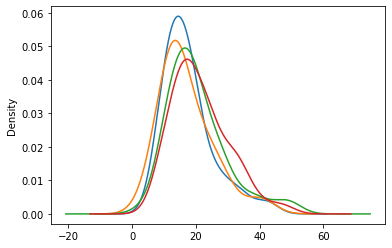

In [44]:
df.groupby('day')['total_bill'].plot(kind='kde')

<IPython.core.display.Javascript object>

<AxesSubplot:xlabel='day', ylabel='total_bill'>

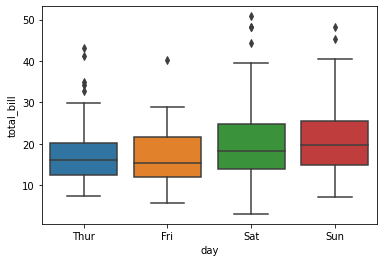

In [45]:
sns.boxplot(y=df.total_bill,x=df.day)

In [46]:
## Assuption -1 : test of Normality
print(st.shapiro(Ttb),st.shapiro(Ftb),st.shapiro(Satb),st.shapiro(Sutb))

ShapiroResult(statistic=0.8844885230064392, pvalue=2.8570884751388803e-05) ShapiroResult(statistic=0.8957934975624084, pvalue=0.04085645452141762) ShapiroResult(statistic=0.9034755825996399, pvalue=7.992002792889252e-06) ShapiroResult(statistic=0.9479389190673828, pvalue=0.003565954277291894)


Note: bypass this normality if sample sizes are >30; 

Ftb is following normal based on  p value(0.04) > alpha(0.01)

In [48]:
## Assumption-2 Variance Equality
st.levene(Ttb,Ftb,Satb,Sutb)

LeveneResult(statistic=0.6653578279881612, pvalue=0.5740792267812198)

since p value(0.5) >alpha(0.01) --> fail to reject H0;

hence we can conclude that all population variances are equal

H0: All pop means are equal 

H1: one of the pop means is different

In [49]:
alpha=0.01
st.f_oneway(Ttb,Ftb,Satb,Sutb)

F_onewayResult(statistic=2.7674794432863363, pvalue=0.04245383328952047)

In [50]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [51]:
m1= ols('df.total_bill~day', data=df).fit()
anova_table= anova_lm(m1)
anova_table

,df,sum_sq,mean_sq,F,PR(>F)
day,3.0,643.941362,214.647121,2.767479,0.042454
Residual,240.0,18614.522721,77.560511,NaN,NaN


In [52]:
## F critical
st.f.isf(alpha, 3,240)

3.8642309599914926

In [53]:
# p value
st.f.sf(2.767479,3,240)

0.042453857901598724

In [ ]:
## non paramtric test - Kruskal wallis\
# H0: all pop medians are equal
# H1: any one pop median is different 


In [54]:
st.kruskal(Ttb,Ftb,Satb,Sutb)

KruskalResult(statistic=10.403076391437086, pvalue=0.01543300820104127)

based on p value - write inference 

## Goodness of fit test

Test the claim that the random machine(1 to 5) is fit for goodness withe sample run of 100 times: obs= [23,15,19,24,19]

In [58]:
alpha =0.05
obs= np.array([23,15,19,24,19])
exp= np.array([20]*5)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

H0: It is good fit  ( Obs = Exp)

H1: It is not goodfit ( Obs != Exp)

In [56]:
st.chisquare(obs, exp)

Power_divergenceResult(statistic=2.5999999999999996, pvalue=0.6268231239782291)

In [59]:
# chi square critical
st.chi2.isf(alpha, 4)

9.487729036781158

In [57]:
## P value
st.chi2.sf(2.5999999999999996, 4)  ## no of col -1 or no of rows -1

0.6268231239782291

since p value(0.62) > alpha (0.05) --> fail to reject H0;

Hence we can conclude that the machine is goodfit for randomness.